# Лабораторная работа 3: Аппроксимация функций нейронными сетями

**Вариант:**
- Z = 5 — Равномерное распределение
- f1 = квадратичная функция: f1(x) = x²
- f2 = f2(x,y) = √x - √y

## Импорт библиотек

In [319]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.interpolate import Rbf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

## 1. Генерация данных и разделение на обучающую и тестирующую выборки

In [320]:
# Параметры генерации
M = 500  # количество наблюдений

# Z = 5: Равномерное распределение
# Для f1(x) — один аргумент
X1 = np.random.uniform(-2, 2, M).reshape(-1, 1)
y1 = X1.flatten() ** 2  # f1(x) = x^2

# Для f2(x,y) — два аргумента (x>0, y>0 для корня)
X2 = np.random.uniform(0.01, 4, (M, 2))
y2 = np.sqrt(X2[:, 0]) - np.sqrt(X2[:, 1])  # f2(x,y) = sqrt(x) - sqrt(y)

print(f"Размерность X1: {X1.shape}, y1: {y1.shape}")
print(f"Размерность X2: {X2.shape}, y2: {y2.shape}")

Размерность X1: (500, 1), y1: (500,)
Размерность X2: (500, 2), y2: (500,)


In [321]:
# Разделение на обучающую и тестирующую выборки (80/20)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"f1: train={X1_train.shape[0]}, test={X1_test.shape[0]}")
print(f"f2: train={X2_train.shape[0]}, test={X2_test.shape[0]}")

f1: train=400, test=100
f2: train=400, test=100


In [322]:
# Масштабирование данных
scaler_X1 = StandardScaler()
scaler_y1 = StandardScaler()

X1_train_scaled = scaler_X1.fit_transform(X1_train)
X1_test_scaled = scaler_X1.transform(X1_test)
y1_train_scaled = scaler_y1.fit_transform(y1_train.reshape(-1, 1)).flatten()
y1_test_scaled = scaler_y1.transform(y1_test.reshape(-1, 1)).flatten()

scaler_X2 = StandardScaler()
scaler_y2 = StandardScaler()

X2_train_scaled = scaler_X2.fit_transform(X2_train)
X2_test_scaled = scaler_X2.transform(X2_test)
y2_train_scaled = scaler_y2.fit_transform(y2_train.reshape(-1, 1)).flatten()
y2_test_scaled = scaler_y2.transform(y2_test.reshape(-1, 1)).flatten()

## 2. Аппроксимация f1(x) = x² с помощью сети прямого распространения (MLP)

In [323]:
# Обучение MLP для f1
mlp_f1 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)

mlp_f1.fit(X1_train_scaled, y1_train_scaled)

# Предсказания
y1_train_pred_mlp_scaled = mlp_f1.predict(X1_train_scaled)
y1_test_pred_mlp_scaled = mlp_f1.predict(X1_test_scaled)

# Обратное преобразование
y1_train_pred_mlp = scaler_y1.inverse_transform(y1_train_pred_mlp_scaled.reshape(-1, 1)).flatten()
y1_test_pred_mlp = scaler_y1.inverse_transform(y1_test_pred_mlp_scaled.reshape(-1, 1)).flatten()

# Метрики
mse_train_mlp_f1 = mean_squared_error(y1_train, y1_train_pred_mlp)
mse_test_mlp_f1 = mean_squared_error(y1_test, y1_test_pred_mlp)
mae_train_mlp_f1 = mean_absolute_error(y1_train, y1_train_pred_mlp)
mae_test_mlp_f1 = mean_absolute_error(y1_test, y1_test_pred_mlp)
r2_train_mlp_f1 = r2_score(y1_train, y1_train_pred_mlp)
r2_test_mlp_f1 = r2_score(y1_test, y1_test_pred_mlp)

print(f"MLP f1: MSE train={mse_train_mlp_f1:.4f}, test={mse_test_mlp_f1:.4f}")
print(f"MLP f1: MAE train={mae_train_mlp_f1:.4f}, test={mae_test_mlp_f1:.4f}")
print(f"MLP f1: R2  train={r2_train_mlp_f1:.4f}, test={r2_test_mlp_f1:.4f}")

MLP f1: MSE train=0.0059, test=0.0065
MLP f1: MAE train=0.0545, test=0.0565
MLP f1: R2  train=0.9960, test=0.9960


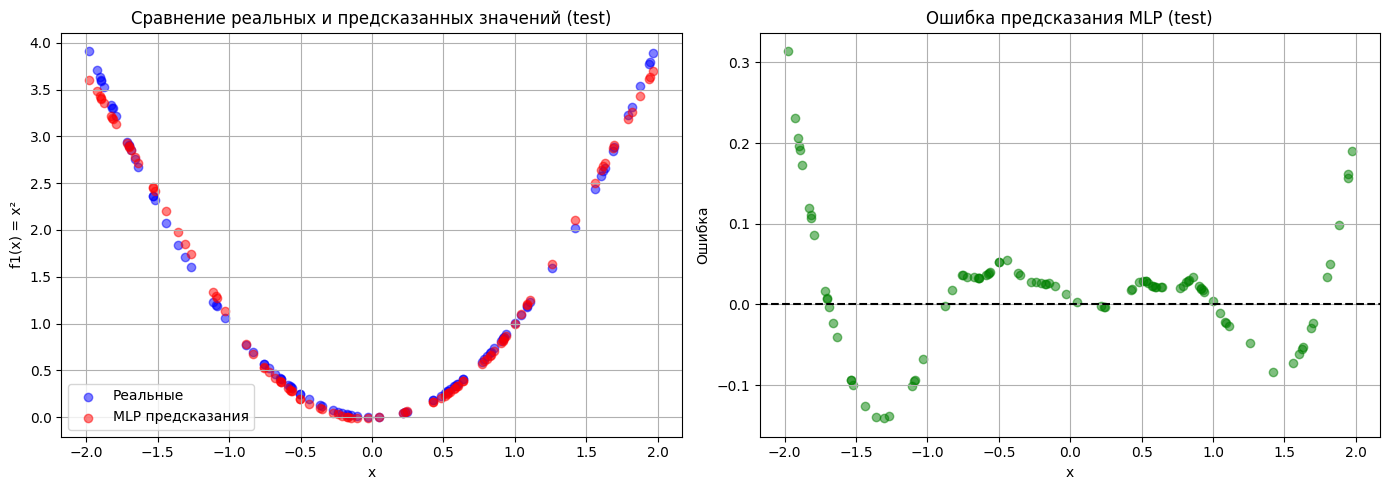

In [324]:
# Графики для MLP f1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сравнение предсказаний и реальных значений (test)
axes[0].scatter(X1_test, y1_test, alpha=0.5, label='Реальные', color='blue')
axes[0].scatter(X1_test, y1_test_pred_mlp, alpha=0.5, label='MLP предсказания', color='red')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f1(x) = x²')
axes[0].set_title('Сравнение реальных и предсказанных значений (test)')
axes[0].legend()
axes[0].grid(True)

# Ошибки
errors_test_mlp_f1 = y1_test - y1_test_pred_mlp
axes[1].scatter(X1_test, errors_test_mlp_f1, color='green', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка предсказания MLP (test)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Аппроксимация f1(x) = x² с помощью RBF-сети

In [325]:
# RBF-сеть для f1 (1 аргумент)
rbf_f1 = Rbf(X1_train.flatten(), y1_train, function='multiquadric')

# Предсказания
y1_train_pred_rbf = rbf_f1(X1_train.flatten())
y1_test_pred_rbf = rbf_f1(X1_test.flatten())

# Метрики
mse_train_rbf_f1 = mean_squared_error(y1_train, y1_train_pred_rbf)
mse_test_rbf_f1 = mean_squared_error(y1_test, y1_test_pred_rbf)
mae_train_rbf_f1 = mean_absolute_error(y1_train, y1_train_pred_rbf)
mae_test_rbf_f1 = mean_absolute_error(y1_test, y1_test_pred_rbf)
r2_train_rbf_f1 = r2_score(y1_train, y1_train_pred_rbf)
r2_test_rbf_f1 = r2_score(y1_test, y1_test_pred_rbf)

print(f"RBF f1: MSE train={mse_train_rbf_f1:.4f}, test={mse_test_rbf_f1:.4f}")
print(f"RBF f1: MAE train={mae_train_rbf_f1:.4f}, test={mae_test_rbf_f1:.4f}")
print(f"RBF f1: R2  train={r2_train_rbf_f1:.4f}, test={r2_test_rbf_f1:.4f}")

RBF f1: MSE train=0.0000, test=0.0000
RBF f1: MAE train=0.0000, test=0.0001
RBF f1: R2  train=1.0000, test=1.0000


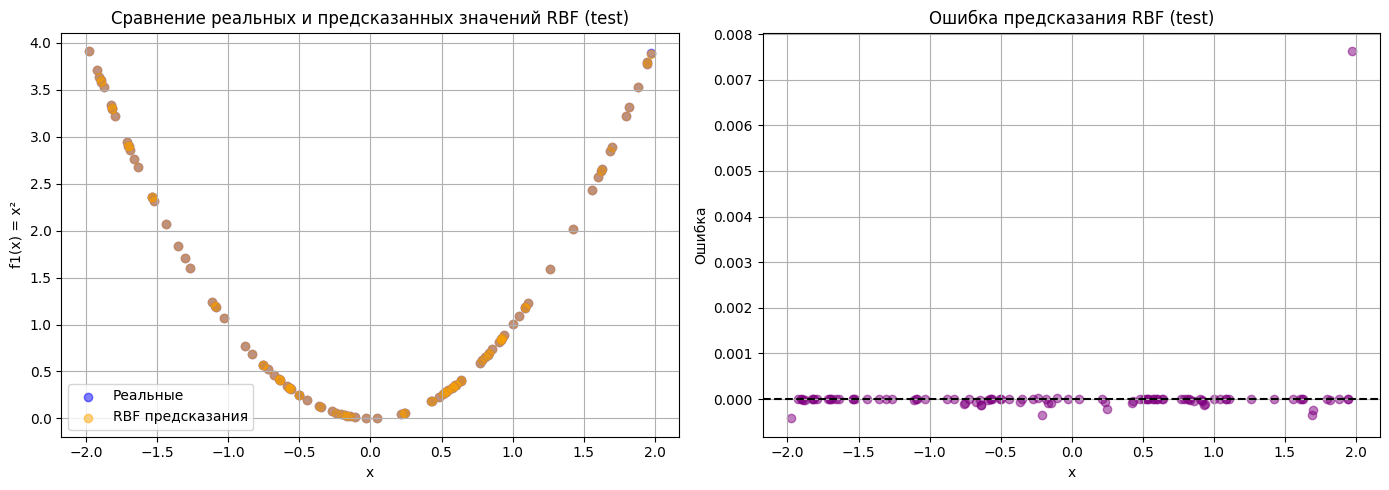

In [326]:
# Графики для RBF f1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X1_test, y1_test, alpha=0.5, label='Реальные', color='blue')
axes[0].scatter(X1_test, y1_test_pred_rbf, alpha=0.5, label='RBF предсказания', color='orange')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f1(x) = x²')
axes[0].set_title('Сравнение реальных и предсказанных значений RBF (test)')
axes[0].legend()
axes[0].grid(True)

errors_test_rbf_f1 = y1_test - y1_test_pred_rbf
axes[1].scatter(X1_test, errors_test_rbf_f1, color='purple', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка предсказания RBF (test)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Аппроксимация f1(x) = x² с помощью нейро-нечеткой сети ANFIS

### Набор правил ANFIS

Для $f_1$ в модели используется $N=10$ правил.

**Правило $i$**:

- параметры гауссианы $c_i$ и $\sigma_i$ (берутся из `centers` и `sigmas`)
- константа в заключении $p_i$ (берётся из `rule_weights.weight`)

Запись правила:

- **Правило $i$**: ЕСЛИ $x$ принадлежит $A_i$, ТО $y=p_i$.

Функция принадлежности:

$$
\mu_i(x)=\exp\left(-\frac{(x-c_i)^2}{2\sigma_i^2}\right)
$$

Дальше считаются активации и выход:

$$
w_i=\mu_i(x),\quad \bar{w}_i=\frac{w_i}{\sum_{j=1}^{N} w_j},\quad \hat{y}=\sum_{i=1}^{N} \bar{w}_i\,p_i
$$

In [327]:
# Класс ANFIS
class ANFIS(nn.Module):
    def __init__(self, n_inputs, n_rules):
        super(ANFIS, self).__init__()
        self.n_inputs = n_inputs
        self.n_rules = n_rules
        self.centers = nn.Parameter(torch.rand(n_inputs, n_rules))
        self.sigmas = nn.Parameter(torch.rand(n_inputs, n_rules))
        self.rule_weights = nn.Linear(n_rules, 1, bias=False)

    def gaussian_membership(self, x):
        return torch.exp(-((x.unsqueeze(-1) - self.centers) ** 2 / (2 * self.sigmas ** 2)))

    def forward(self, x):
        membership_values = self.gaussian_membership(x)
        rule_activation = torch.prod(membership_values, dim=1)
        rule_activation_normalized = rule_activation / rule_activation.sum(dim=1, keepdim=True)
        output = self.rule_weights(rule_activation_normalized)
        return output.squeeze()


class AnfisDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]

## Гауссианы в RBF (f1)

RBF‑аппроксимация может быть записана как сумма гауссовых базисных функций.

Ниже показаны отдельные взвешенные гауссианы и их сумма для приближения $f_1(x)=x^2$.

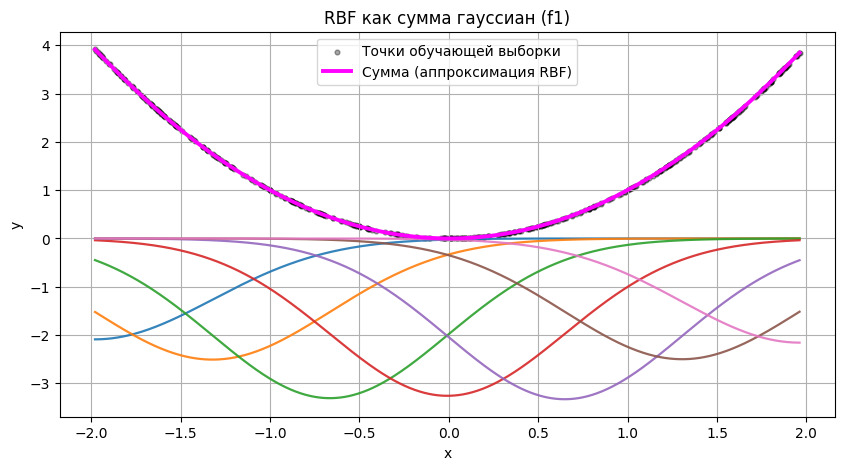

n_centers=7, sigma≈0.6570
weights (p_i)= [-2.089  -2.5082 -3.307  -3.2578 -3.3288 -2.5003 -2.157 ] bias= 8.0087


In [328]:
import numpy as np
import matplotlib.pyplot as plt


def fit_gaussian_rbf_1d(x_train, y_train, n_centers=7, sigma=None):
    """Простая RBF-модель: сумма гауссиан + линейная регрессия по весам."""
    x_train = np.asarray(x_train).reshape(-1)
    y_train = np.asarray(y_train).reshape(-1)

    # центры равномерно по диапазону x
    c = np.linspace(x_train.min(), x_train.max(), n_centers)

    # если sigma не задан, берём шаг между центрами
    if sigma is None:
        if n_centers > 1:
            sigma = (c[1] - c[0])
        else:
            sigma = (x_train.max() - x_train.min()) / 2
        sigma = float(abs(sigma)) + 1e-8

    # матрица базисных функций Phi (N, M)
    Phi = np.exp(-((x_train[:, None] - c[None, :]) ** 2) / (2 * sigma**2))

    # добавим свободный член
    A = np.c_[np.ones(Phi.shape[0]), Phi]

    # веса по МНК
    w, *_ = np.linalg.lstsq(A, y_train, rcond=None)
    b = w[0]
    weights = w[1:]

    return c, sigma, weights, b


# Данные обучения для f1
x_train = np.asarray(X1_train).reshape(-1)
y_train = np.asarray(y1_train).reshape(-1)

centers, sigma, w, b = fit_gaussian_rbf_1d(x_train, y_train, n_centers=7, sigma=None)

# сетка для графика
x_grid = np.linspace(x_train.min(), x_train.max(), 1000)
phi_grid = np.exp(-((x_grid[:, None] - centers[None, :]) ** 2) / (2 * sigma**2))

# вклады отдельных гауссиан (МОГУТ быть отрицательными из-за весов)
components = phi_grid * w[None, :]

# суммарная кривая (аппроксимация)
sum_curve = b + components.sum(axis=1)

plt.figure(figsize=(10, 5))

# точки исходной функции
plt.scatter(x_train, y_train, s=12, alpha=0.35, color='black', label='Точки обучающей выборки')

# отдельные гауссианы (вклады)
for i in range(components.shape[1]):
    plt.plot(x_grid, components[:, i], linewidth=1.6, alpha=0.9)

# суммарная кривая
plt.plot(x_grid, sum_curve, color='magenta', linewidth=2.8, label='Сумма (аппроксимация RBF)')

plt.title('RBF как сумма гауссиан (f1)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

print(f"n_centers={len(centers)}, sigma≈{sigma:.4f}")
print('weights (p_i)=', np.round(w, 4), 'bias=', round(float(b), 4))

In [329]:
# Подготовка данных для ANFIS f1
n_inputs_f1 = 1
n_rules_f1 = 10

model_anfis_f1 = ANFIS(n_inputs_f1, n_rules_f1)
criterion = nn.MSELoss()
mae_criterion = nn.L1Loss()
optimizer = optim.Adam(model_anfis_f1.parameters(), lr=0.01)

train_dataset_f1 = AnfisDataset(X1_train_scaled, y1_train_scaled)
test_dataset_f1 = AnfisDataset(X1_test_scaled, y1_test_scaled)
train_loader_f1 = DataLoader(train_dataset_f1, batch_size=32, shuffle=True)
test_loader_f1 = DataLoader(test_dataset_f1, batch_size=32, shuffle=False)

n_epochs = 100
loss_history_f1 = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader_f1:
        optimizer.zero_grad()
        y_pred = model_anfis_f1(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            mae_loss = mae_criterion(y_pred, batch_y)
            epoch_loss += mae_loss.item()
    loss_history_f1.append(epoch_loss / len(train_loader_f1))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, MAE Loss: {epoch_loss / len(train_loader_f1):.4f}")

Epoch 20/100, MAE Loss: 0.0668
Epoch 40/100, MAE Loss: 0.0368
Epoch 60/100, MAE Loss: 0.0202
Epoch 80/100, MAE Loss: 0.0133
Epoch 100/100, MAE Loss: 0.0109


In [330]:
# Предсказания ANFIS для f1
model_anfis_f1.eval()
with torch.no_grad():
    y1_train_pred_anfis_scaled = model_anfis_f1(torch.tensor(X1_train_scaled, dtype=torch.float32)).numpy()
    y1_test_pred_anfis_scaled = model_anfis_f1(torch.tensor(X1_test_scaled, dtype=torch.float32)).numpy()

y1_train_pred_anfis = scaler_y1.inverse_transform(y1_train_pred_anfis_scaled.reshape(-1, 1)).flatten()
y1_test_pred_anfis = scaler_y1.inverse_transform(y1_test_pred_anfis_scaled.reshape(-1, 1)).flatten()

mse_train_anfis_f1 = mean_squared_error(y1_train, y1_train_pred_anfis)
mse_test_anfis_f1 = mean_squared_error(y1_test, y1_test_pred_anfis)
mae_train_anfis_f1 = mean_absolute_error(y1_train, y1_train_pred_anfis)
mae_test_anfis_f1 = mean_absolute_error(y1_test, y1_test_pred_anfis)
r2_train_anfis_f1 = r2_score(y1_train, y1_train_pred_anfis)
r2_test_anfis_f1 = r2_score(y1_test, y1_test_pred_anfis)

print(f"ANFIS f1: MSE train={mse_train_anfis_f1:.4f}, test={mse_test_anfis_f1:.4f}")
print(f"ANFIS f1: MAE train={mae_train_anfis_f1:.4f}, test={mae_test_anfis_f1:.4f}")
print(f"ANFIS f1: R2  train={r2_train_anfis_f1:.4f}, test={r2_test_anfis_f1:.4f}")

ANFIS f1: MSE train=0.0005, test=0.0005
ANFIS f1: MAE train=0.0132, test=0.0136
ANFIS f1: R2  train=0.9997, test=0.9997


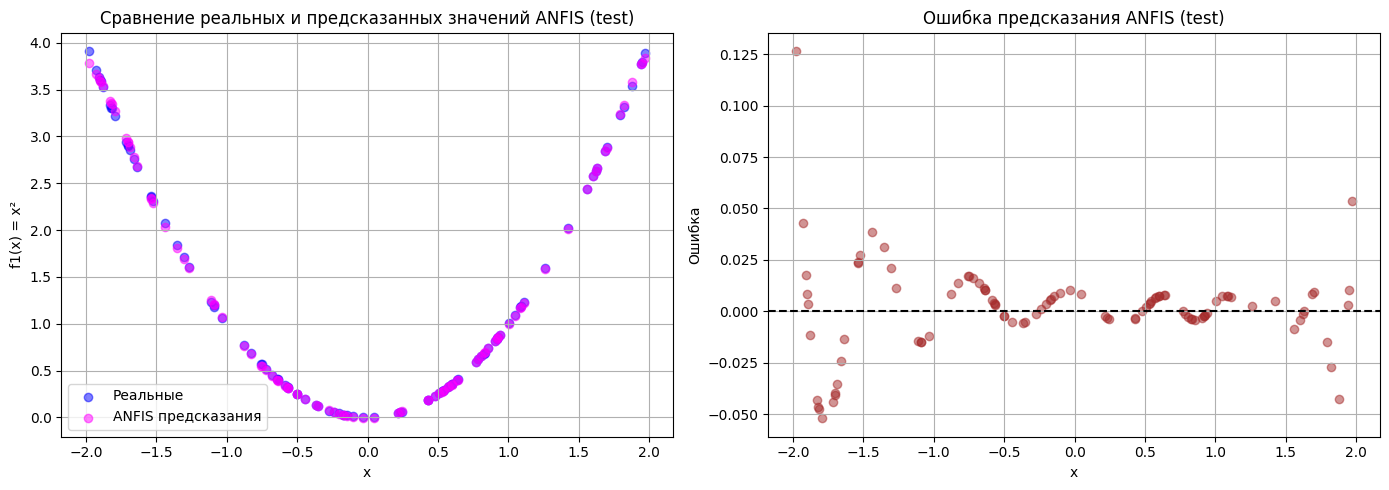

In [331]:
# Графики ANFIS f1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X1_test, y1_test, alpha=0.5, label='Реальные', color='blue')
axes[0].scatter(X1_test, y1_test_pred_anfis, alpha=0.5, label='ANFIS предсказания', color='magenta')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f1(x) = x²')
axes[0].set_title('Сравнение реальных и предсказанных значений ANFIS (test)')
axes[0].legend()
axes[0].grid(True)

errors_test_anfis_f1 = y1_test - y1_test_pred_anfis
axes[1].scatter(X1_test, errors_test_anfis_f1, color='brown', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка предсказания ANFIS (test)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [332]:
# Параметры ANFIS (f1)
print("ANFIS f1:")
print(f"n_inputs={n_inputs_f1}, n_rules={n_rules_f1}")
print("centers shape:", tuple(model_anfis_f1.centers.shape))
print("sigmas  shape:", tuple(model_anfis_f1.sigmas.shape))
print("weights shape:", tuple(model_anfis_f1.rule_weights.weight.shape))

ANFIS f1:
n_inputs=1, n_rules=10
centers shape: (1, 10)
sigmas  shape: (1, 10)
weights shape: (1, 10)


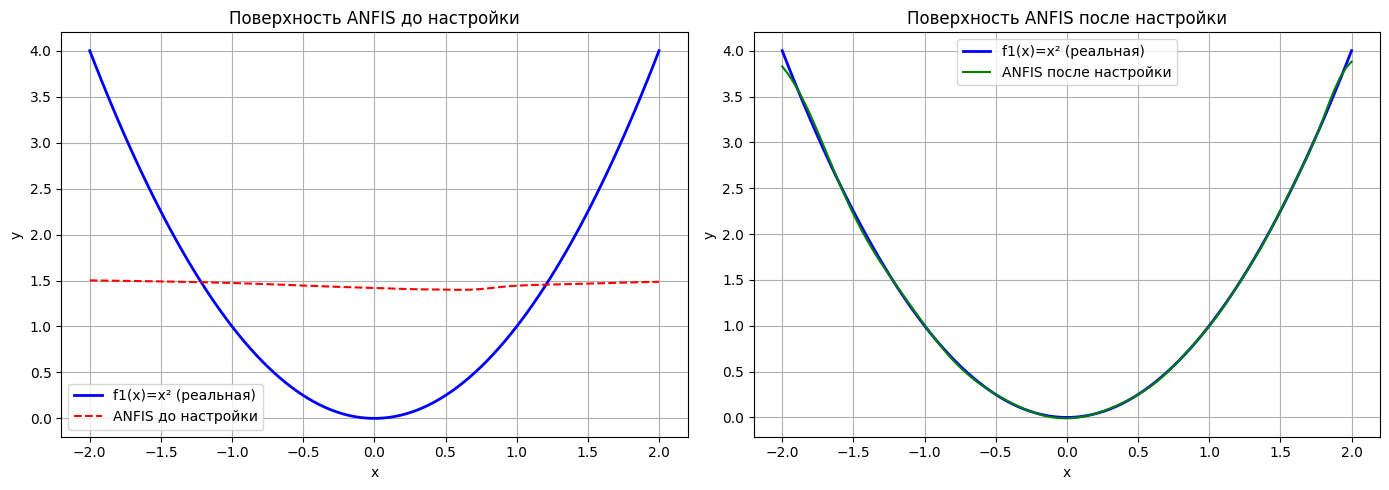

In [333]:
# Поверхность ANFIS до и после настройки (для f1)
x_range = np.linspace(-2, 2, 100).reshape(-1, 1)
x_range_scaled = scaler_X1.transform(x_range)

# До настройки — случайные параметры
random_model = ANFIS(n_inputs_f1, n_rules_f1)
random_model.eval()
with torch.no_grad():
    y_before = random_model(torch.tensor(x_range_scaled, dtype=torch.float32)).numpy()
y_before_orig = scaler_y1.inverse_transform(y_before.reshape(-1, 1)).flatten()

# После настройки
model_anfis_f1.eval()
with torch.no_grad():
    y_after = model_anfis_f1(torch.tensor(x_range_scaled, dtype=torch.float32)).numpy()
y_after_orig = scaler_y1.inverse_transform(y_after.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_range.flatten(), x_range.flatten()**2, 'b-', label='f1(x)=x² (реальная)', linewidth=2)
axes[0].plot(x_range.flatten(), y_before_orig, 'r--', label='ANFIS до настройки')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Поверхность ANFIS до настройки')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_range.flatten(), x_range.flatten()**2, 'b-', label='f1(x)=x² (реальная)', linewidth=2)
axes[1].plot(x_range.flatten(), y_after_orig, 'g-', label='ANFIS после настройки')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Поверхность ANFIS после настройки')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Сравнение методов для f1(x) = x²

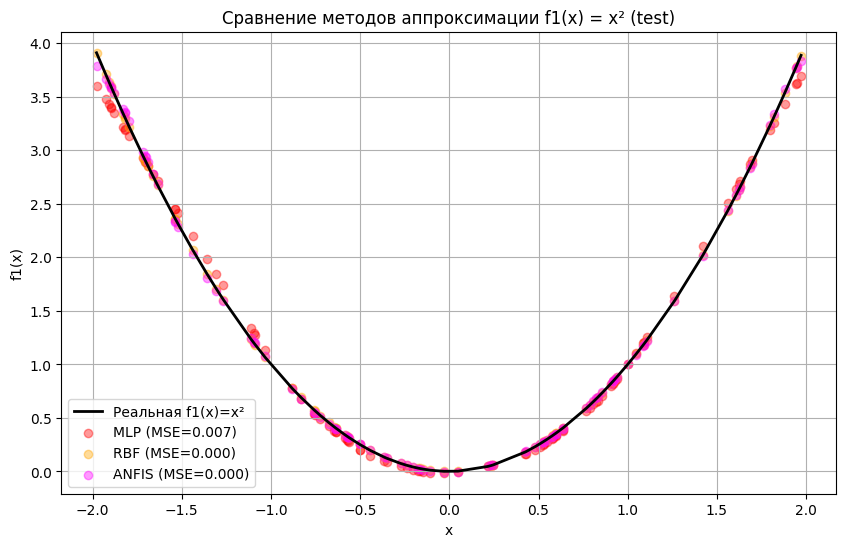

In [334]:
# Сводный график сравнения всех методов для f1
fig, ax = plt.subplots(figsize=(10, 6))

x_sorted_idx = np.argsort(X1_test.flatten())
x_sorted = X1_test[x_sorted_idx].flatten()
y_sorted = y1_test[x_sorted_idx]
y_mlp_sorted = y1_test_pred_mlp[x_sorted_idx]
y_rbf_sorted = y1_test_pred_rbf[x_sorted_idx]
y_anfis_sorted = y1_test_pred_anfis[x_sorted_idx]

ax.plot(x_sorted, y_sorted, 'k-', label='Реальная f1(x)=x²', linewidth=2)
ax.scatter(x_sorted, y_mlp_sorted, alpha=0.4, label=f'MLP (MSE={mse_test_mlp_f1:.3f})', color='red')
ax.scatter(x_sorted, y_rbf_sorted, alpha=0.4, label=f'RBF (MSE={mse_test_rbf_f1:.3f})', color='orange')
ax.scatter(x_sorted, y_anfis_sorted, alpha=0.4, label=f'ANFIS (MSE={mse_test_anfis_f1:.3f})', color='magenta')
ax.set_xlabel('x')
ax.set_ylabel('f1(x)')
ax.set_title('Сравнение методов аппроксимации f1(x) = x² (test)')
ax.legend()
ax.grid(True)
plt.show()

## 5. Аппроксимация f2(x,y) = √x - √y с помощью MLP

In [335]:
# Обучение MLP для f2
mlp_f2 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)

mlp_f2.fit(X2_train_scaled, y2_train_scaled)

y2_train_pred_mlp_scaled = mlp_f2.predict(X2_train_scaled)
y2_test_pred_mlp_scaled = mlp_f2.predict(X2_test_scaled)

y2_train_pred_mlp = scaler_y2.inverse_transform(y2_train_pred_mlp_scaled.reshape(-1, 1)).flatten()
y2_test_pred_mlp = scaler_y2.inverse_transform(y2_test_pred_mlp_scaled.reshape(-1, 1)).flatten()

mse_train_mlp_f2 = mean_squared_error(y2_train, y2_train_pred_mlp)
mse_test_mlp_f2 = mean_squared_error(y2_test, y2_test_pred_mlp)
mae_train_mlp_f2 = mean_absolute_error(y2_train, y2_train_pred_mlp)
mae_test_mlp_f2 = mean_absolute_error(y2_test, y2_test_pred_mlp)
r2_train_mlp_f2 = r2_score(y2_train, y2_train_pred_mlp)
r2_test_mlp_f2 = r2_score(y2_test, y2_test_pred_mlp)

print(f"MLP f2: MSE train={mse_train_mlp_f2:.4f}, test={mse_test_mlp_f2:.4f}")
print(f"MLP f2: MAE train={mae_train_mlp_f2:.4f}, test={mae_test_mlp_f2:.4f}")
print(f"MLP f2: R2  train={r2_train_mlp_f2:.4f}, test={r2_test_mlp_f2:.4f}")

MLP f2: MSE train=0.0022, test=0.0027
MLP f2: MAE train=0.0302, test=0.0345
MLP f2: R2  train=0.9951, test=0.9935


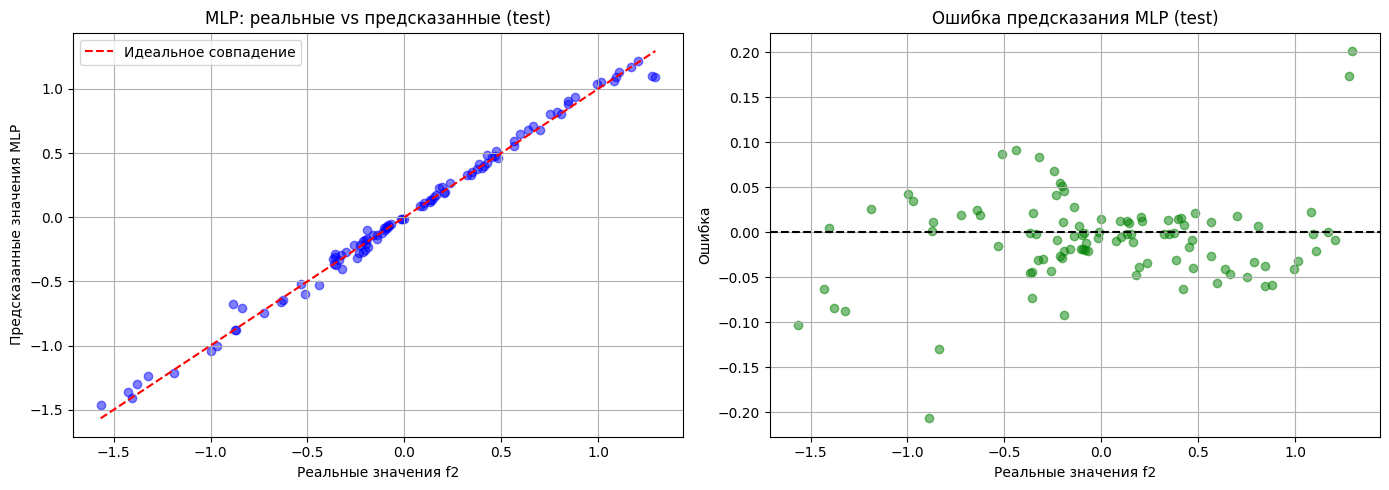

In [336]:
# Графики для MLP f2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y2_test, y2_test_pred_mlp, alpha=0.5, color='blue')
axes[0].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--', label='Идеальное совпадение')
axes[0].set_xlabel('Реальные значения f2')
axes[0].set_ylabel('Предсказанные значения MLP')
axes[0].set_title('MLP: реальные vs предсказанные (test)')
axes[0].legend()
axes[0].grid(True)

errors_test_mlp_f2 = y2_test - y2_test_pred_mlp
axes[1].scatter(y2_test, errors_test_mlp_f2, color='green', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Реальные значения f2')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка предсказания MLP (test)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Аппроксимация f2(x,y) = √x - √y с помощью RBF-сети

In [337]:
# RBF-сеть для f2 (2 аргумента)
rbf_f2 = Rbf(X2_train[:, 0], X2_train[:, 1], y2_train, function='multiquadric')

y2_train_pred_rbf = rbf_f2(X2_train[:, 0], X2_train[:, 1])
y2_test_pred_rbf = rbf_f2(X2_test[:, 0], X2_test[:, 1])

mse_train_rbf_f2 = mean_squared_error(y2_train, y2_train_pred_rbf)
mse_test_rbf_f2 = mean_squared_error(y2_test, y2_test_pred_rbf)
mae_train_rbf_f2 = mean_absolute_error(y2_train, y2_train_pred_rbf)
mae_test_rbf_f2 = mean_absolute_error(y2_test, y2_test_pred_rbf)
r2_train_rbf_f2 = r2_score(y2_train, y2_train_pred_rbf)
r2_test_rbf_f2 = r2_score(y2_test, y2_test_pred_rbf)

print(f"RBF f2: MSE train={mse_train_rbf_f2:.4f}, test={mse_test_rbf_f2:.4f}")
print(f"RBF f2: MAE train={mae_train_rbf_f2:.4f}, test={mae_test_rbf_f2:.4f}")
print(f"RBF f2: R2  train={r2_train_rbf_f2:.4f}, test={r2_test_rbf_f2:.4f}")

RBF f2: MSE train=0.0000, test=0.0003
RBF f2: MAE train=0.0000, test=0.0040
RBF f2: R2  train=1.0000, test=0.9993


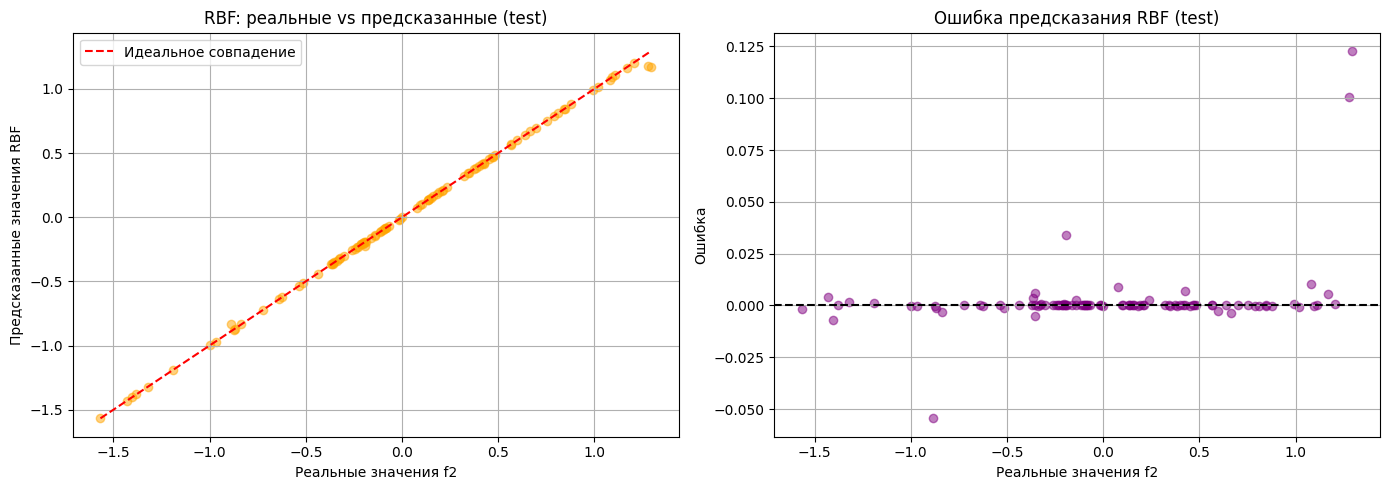

In [338]:
# Графики для RBF f2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y2_test, y2_test_pred_rbf, alpha=0.5, color='orange')
axes[0].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--', label='Идеальное совпадение')
axes[0].set_xlabel('Реальные значения f2')
axes[0].set_ylabel('Предсказанные значения RBF')
axes[0].set_title('RBF: реальные vs предсказанные (test)')
axes[0].legend()
axes[0].grid(True)

errors_test_rbf_f2 = y2_test - y2_test_pred_rbf
axes[1].scatter(y2_test, errors_test_rbf_f2, color='purple', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Реальные значения f2')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка предсказания RBF (test)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Аппроксимация f2(x,y) = √x - √y с помощью ANFIS

### Набор правил ANFIS

Для $f_2$ в модели $N=15$ правил.

Правило $i$ задаётся параметрами для двух входов:

- для $x$: $c_{x,i},\sigma_{x,i}$ (из `centers` и `sigmas`)
- для $y$: $c_{y,i},\sigma_{y,i}$ (из `centers` и `sigmas`)
- константа $p_i$ (вес из `rule_weights.weight`)

- **Правило $i$**: ЕСЛИ $x$ принадлежит $A_i$ И $y$ принадлежит $B_i$, ТО $z=p_i$.

$$
\mu_{x,i}(x)=\exp\left(-\frac{(x-c_{x,i})^2}{2\sigma_{x,i}^2}\right),\quad
\mu_{y,i}(y)=\exp\left(-\frac{(y-c_{y,i})^2}{2\sigma_{y,i}^2}\right)
$$

Дальше считаются активации и выход:

$$
w_i=\mu_{x,i}(x)\cdot\mu_{y,i}(y),\quad \bar{w}_i=\frac{w_i}{\sum_{j=1}^{N} w_j},\quad \hat{z}=\sum_{i=1}^{N} \bar{w}_i\,p_i
$$

In [339]:
# ANFIS для f2 (2 входа)
n_inputs_f2 = 2
n_rules_f2 = 15

model_anfis_f2 = ANFIS(n_inputs_f2, n_rules_f2)
optimizer_f2 = optim.Adam(model_anfis_f2.parameters(), lr=0.01)

train_dataset_f2 = AnfisDataset(X2_train_scaled, y2_train_scaled)
test_dataset_f2 = AnfisDataset(X2_test_scaled, y2_test_scaled)
train_loader_f2 = DataLoader(train_dataset_f2, batch_size=32, shuffle=True)
test_loader_f2 = DataLoader(test_dataset_f2, batch_size=32, shuffle=False)

n_epochs = 100
loss_history_f2 = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader_f2:
        optimizer_f2.zero_grad()
        y_pred = model_anfis_f2(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer_f2.step()
        with torch.no_grad():
            mae_loss = mae_criterion(y_pred, batch_y)
            epoch_loss += mae_loss.item()
    loss_history_f2.append(epoch_loss / len(train_loader_f2))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, MAE Loss: {epoch_loss / len(train_loader_f2):.4f}")

Epoch 20/100, MAE Loss: 0.0570
Epoch 40/100, MAE Loss: 0.0358
Epoch 60/100, MAE Loss: 0.0252
Epoch 80/100, MAE Loss: 0.0225
Epoch 100/100, MAE Loss: 0.0197


In [340]:
# Предсказания ANFIS для f2
model_anfis_f2.eval()
with torch.no_grad():
    y2_train_pred_anfis_scaled = model_anfis_f2(torch.tensor(X2_train_scaled, dtype=torch.float32)).numpy()
    y2_test_pred_anfis_scaled = model_anfis_f2(torch.tensor(X2_test_scaled, dtype=torch.float32)).numpy()

y2_train_pred_anfis = scaler_y2.inverse_transform(y2_train_pred_anfis_scaled.reshape(-1, 1)).flatten()
y2_test_pred_anfis = scaler_y2.inverse_transform(y2_test_pred_anfis_scaled.reshape(-1, 1)).flatten()

mse_train_anfis_f2 = mean_squared_error(y2_train, y2_train_pred_anfis)
mse_test_anfis_f2 = mean_squared_error(y2_test, y2_test_pred_anfis)
mae_train_anfis_f2 = mean_absolute_error(y2_train, y2_train_pred_anfis)
mae_test_anfis_f2 = mean_absolute_error(y2_test, y2_test_pred_anfis)
r2_train_anfis_f2 = r2_score(y2_train, y2_train_pred_anfis)
r2_test_anfis_f2 = r2_score(y2_test, y2_test_pred_anfis)

print(f"ANFIS f2: MSE train={mse_train_anfis_f2:.4f}, test={mse_test_anfis_f2:.4f}")
print(f"ANFIS f2: MAE train={mae_train_anfis_f2:.4f}, test={mae_test_anfis_f2:.4f}")
print(f"ANFIS f2: R2  train={r2_train_anfis_f2:.4f}, test={r2_test_anfis_f2:.4f}")

ANFIS f2: MSE train=0.0004, test=0.0003
ANFIS f2: MAE train=0.0128, test=0.0128
ANFIS f2: R2  train=0.9990, test=0.9992


## Гауссианы в RBF (f2)

Для $f_2(x,y)=\sqrt{x}-\sqrt{y}$ входов два, поэтому визуализация делается по срезам:

- $y=y_0$ (график по $x$)
- $x=x_0$ (график по $y$)

На каждом графике показаны отдельные взвешенные гауссианы и их сумма.

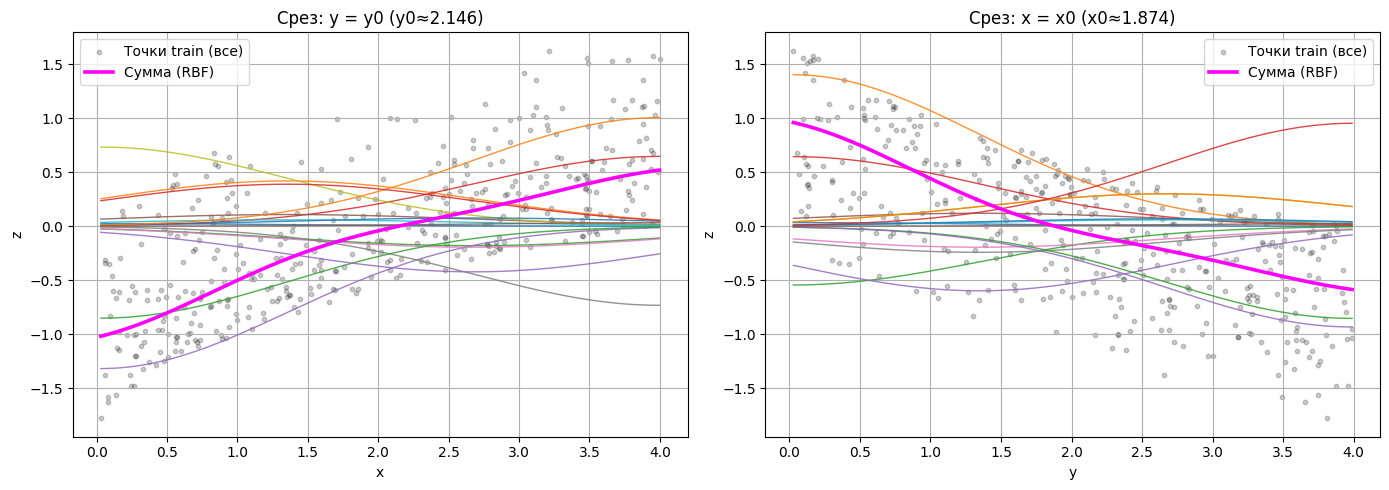

centers=16, sigma_x≈1.3227, sigma_y≈1.3200
weights (p_i) первые 10 = [ 0.0865  1.5149 -0.6543  2.3359 -1.5821  0.1291 -0.2341 -0.8791  0.7918
  0.0628] ... bias= -0.1075


In [341]:
import numpy as np
import matplotlib.pyplot as plt


def fit_gaussian_rbf_2d(X_train, y_train, n_centers_per_dim=4, sigma_x=None, sigma_y=None):
    """RBF для 2D: сумма гауссиан + МНК по весам."""
    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train).reshape(-1)

    x = X_train[:, 0]
    y = X_train[:, 1]

    cx = np.linspace(x.min(), x.max(), n_centers_per_dim)
    cy = np.linspace(y.min(), y.max(), n_centers_per_dim)
    Cx, Cy = np.meshgrid(cx, cy, indexing='xy')
    centers = np.c_[Cx.ravel(), Cy.ravel()]  # (M, 2)

    if sigma_x is None:
        sigma_x = (cx[1] - cx[0]) if n_centers_per_dim > 1 else (x.max() - x.min()) / 2
    if sigma_y is None:
        sigma_y = (cy[1] - cy[0]) if n_centers_per_dim > 1 else (y.max() - y.min()) / 2

    sigma_x = float(abs(sigma_x)) + 1e-8
    sigma_y = float(abs(sigma_y)) + 1e-8

    dx2 = (x[:, None] - centers[None, :, 0]) ** 2 / (2 * sigma_x**2)
    dy2 = (y[:, None] - centers[None, :, 1]) ** 2 / (2 * sigma_y**2)
    Phi = np.exp(-(dx2 + dy2))  # (N, M)

    A = np.c_[np.ones(Phi.shape[0]), Phi]
    w, *_ = np.linalg.lstsq(A, y_train, rcond=None)

    b = w[0]
    weights = w[1:]

    return centers, sigma_x, sigma_y, weights, b


def plot_rbf_gaussians_f2_slices(X_train, y_train, centers, sigma_x, sigma_y, weights, b, n_points=800):
    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train).reshape(-1)

    x_train = X_train[:, 0]
    y_train_in = X_train[:, 1]

    x0 = float(np.median(x_train))
    y0 = float(np.median(y_train_in))

    # Срез 1: y = y0, строим от x
    x_grid = np.linspace(x_train.min(), x_train.max(), n_points)
    dx2g = (x_grid[:, None] - centers[None, :, 0]) ** 2 / (2 * sigma_x**2)
    dy2c = (y0 - centers[:, 1]) ** 2 / (2 * sigma_y**2)
    phi_x = np.exp(-(dx2g + dy2c[None, :]))
    comp_x = phi_x * weights[None, :]
    sum_x = b + comp_x.sum(axis=1)

    # Срез 2: x = x0, строим от y
    y_grid = np.linspace(y_train_in.min(), y_train_in.max(), n_points)
    dx2c = (x0 - centers[:, 0]) ** 2 / (2 * sigma_x**2)
    dy2g = (y_grid[:, None] - centers[None, :, 1]) ** 2 / (2 * sigma_y**2)
    phi_y = np.exp(-(dx2c[None, :] + dy2g))
    comp_y = phi_y * weights[None, :]
    sum_y = b + comp_y.sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # y = y0
    axes[0].scatter(x_train, y_train, s=10, alpha=0.20, color='black', label='Точки train (все)')
    for i in range(comp_x.shape[1]):
        axes[0].plot(x_grid, comp_x[:, i], linewidth=1.0, alpha=0.85)
    axes[0].plot(x_grid, sum_x, color='magenta', linewidth=2.6, label='Сумма (RBF)')
    axes[0].set_title(f'Срез: y = y0 (y0≈{y0:.3f})')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('z')
    axes[0].grid(True)
    axes[0].legend()

    # x = x0
    axes[1].scatter(y_train_in, y_train, s=10, alpha=0.20, color='black', label='Точки train (все)')
    for i in range(comp_y.shape[1]):
        axes[1].plot(y_grid, comp_y[:, i], linewidth=1.0, alpha=0.85)
    axes[1].plot(y_grid, sum_y, color='magenta', linewidth=2.6, label='Сумма (RBF)')
    axes[1].set_title(f'Срез: x = x0 (x0≈{x0:.3f})')
    axes[1].set_xlabel('y')
    axes[1].set_ylabel('z')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Данные обучения для f2
X_train = np.asarray(X2_train)
y_train = np.asarray(y2_train)

centers2, sx2, sy2, w2, b2 = fit_gaussian_rbf_2d(X_train, y_train, n_centers_per_dim=4)
plot_rbf_gaussians_f2_slices(X_train, y_train, centers2, sx2, sy2, w2, b2)

print(f"centers={len(centers2)}, sigma_x≈{sx2:.4f}, sigma_y≈{sy2:.4f}")
print('weights (p_i) первые 10 =', np.round(w2[:10], 4), '... bias=', round(float(b2), 4))

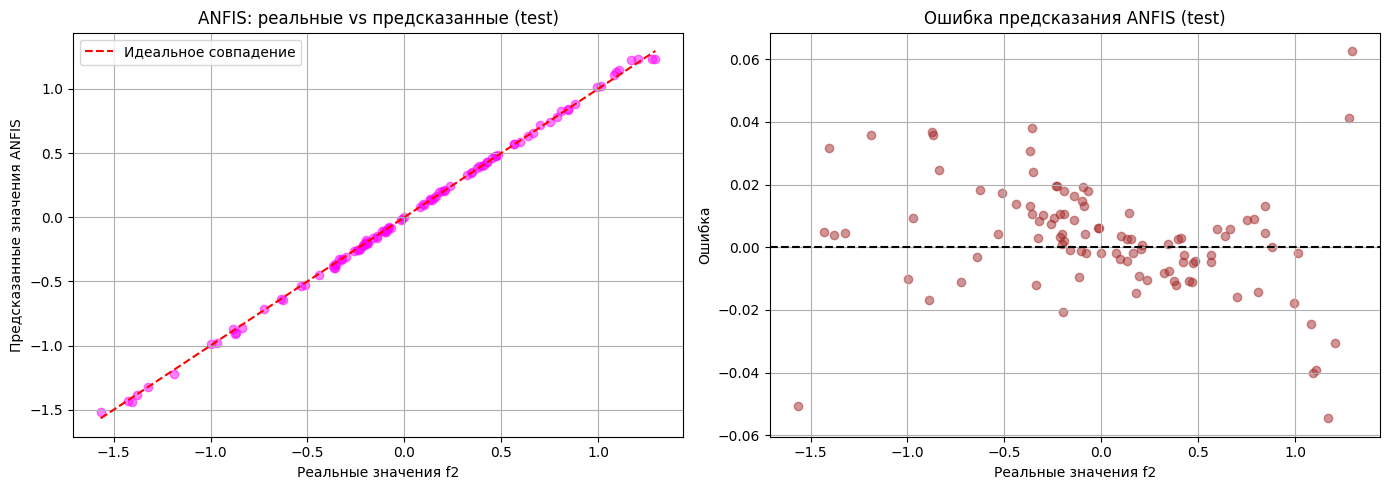

In [342]:
# Графики ANFIS f2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y2_test, y2_test_pred_anfis, alpha=0.5, color='magenta')
axes[0].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--', label='Идеальное совпадение')
axes[0].set_xlabel('Реальные значения f2')
axes[0].set_ylabel('Предсказанные значения ANFIS')
axes[0].set_title('ANFIS: реальные vs предсказанные (test)')
axes[0].legend()
axes[0].grid(True)

errors_test_anfis_f2 = y2_test - y2_test_pred_anfis
axes[1].scatter(y2_test, errors_test_anfis_f2, color='brown', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Реальные значения f2')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка предсказания ANFIS (test)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [343]:
# Параметры ANFIS (f2)
print("ANFIS f2:")
print(f"n_inputs={n_inputs_f2}, n_rules={n_rules_f2}")
print("centers shape:", tuple(model_anfis_f2.centers.shape))
print("sigmas  shape:", tuple(model_anfis_f2.sigmas.shape))
print("weights shape:", tuple(model_anfis_f2.rule_weights.weight.shape))

ANFIS f2:
n_inputs=2, n_rules=15
centers shape: (2, 15)
sigmas  shape: (2, 15)
weights shape: (1, 15)


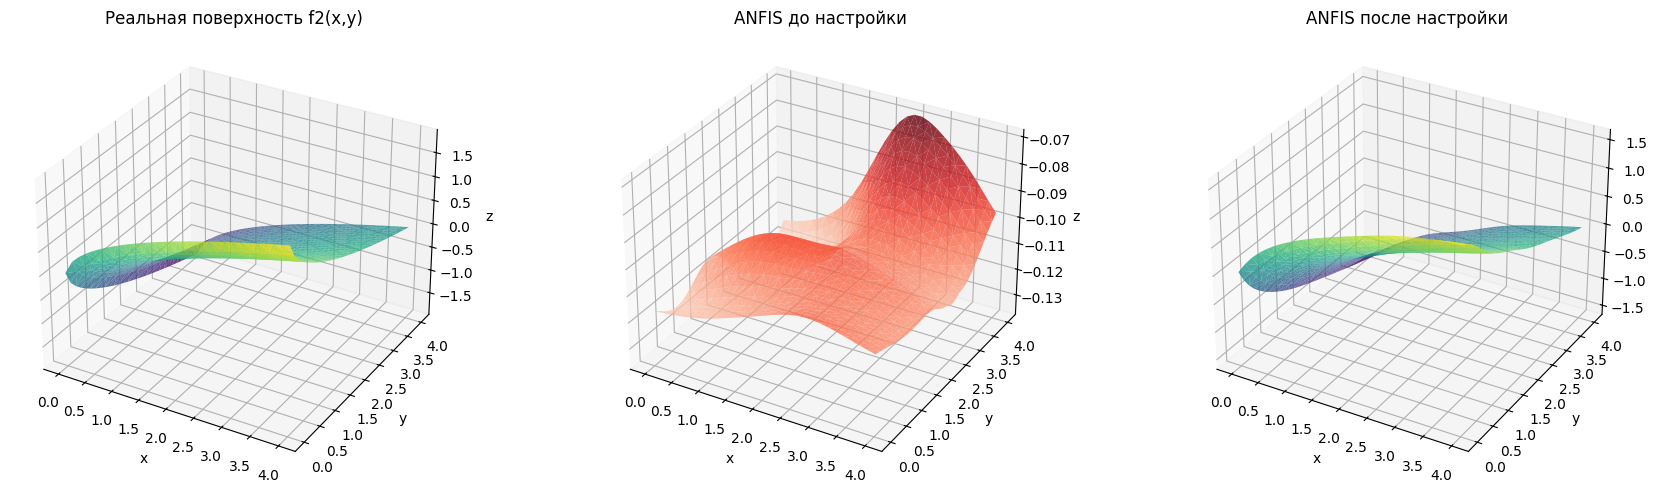

In [344]:
# Поверхность ANFIS до и после настройки для f2
x_grid = np.linspace(0.01, 4, 30)
y_grid = np.linspace(0.01, 4, 30)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
grid_scaled = scaler_X2.transform(grid_points)

# До настройки
random_model_f2 = ANFIS(n_inputs_f2, n_rules_f2)
random_model_f2.eval()
with torch.no_grad():
    z_before = random_model_f2(torch.tensor(grid_scaled, dtype=torch.float32)).numpy()
z_before_orig = scaler_y2.inverse_transform(z_before.reshape(-1, 1)).flatten()

# После настройки
model_anfis_f2.eval()
with torch.no_grad():
    z_after = model_anfis_f2(torch.tensor(grid_scaled, dtype=torch.float32)).numpy()
z_after_orig = scaler_y2.inverse_transform(z_after.reshape(-1, 1)).flatten()

# Реальная поверхность
z_real = np.sqrt(grid_points[:, 0]) - np.sqrt(grid_points[:, 1])

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(grid_points[:, 0], grid_points[:, 1], z_real, cmap='viridis', alpha=0.8)
ax1.set_title('Реальная поверхность f2(x,y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(grid_points[:, 0], grid_points[:, 1], z_before_orig, cmap='Reds', alpha=0.8)
ax2.set_title('ANFIS до настройки')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(grid_points[:, 0], grid_points[:, 1], z_after_orig, cmap='viridis', alpha=0.8)
ax3.set_title('ANFIS после настройки')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('z')

plt.tight_layout()
plt.show()

## Сравнение методов для f2(x,y) = √x - √y

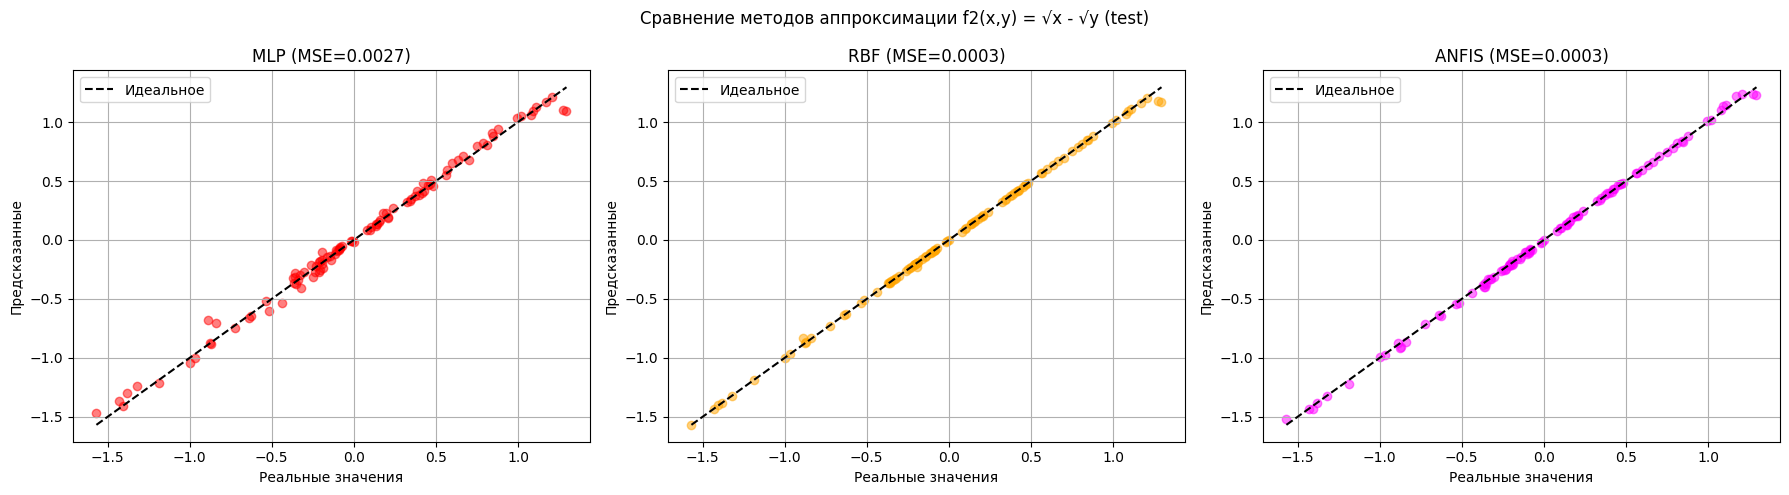

In [345]:
# Сводный график сравнения всех методов для f2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods_f2 = [
    ('MLP', y2_test_pred_mlp, mse_test_mlp_f2, 'red'),
    ('RBF', y2_test_pred_rbf, mse_test_rbf_f2, 'orange'),
    ('ANFIS', y2_test_pred_anfis, mse_test_anfis_f2, 'magenta')
]

for i, (name, preds, mse, color) in enumerate(methods_f2):
    axes[i].scatter(y2_test, preds, alpha=0.5, color=color)
    axes[i].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'k--', label='Идеальное')
    axes[i].set_xlabel('Реальные значения')
    axes[i].set_ylabel('Предсказанные')
    axes[i].set_title(f'{name} (MSE={mse:.4f})')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Сравнение методов аппроксимации f2(x,y) = √x - √y (test)')
plt.tight_layout()
plt.show()

## 8. Итоговая таблица результатов

In [346]:
print("="*80)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)

print("\n--- f1(x) = x² (квадратичная функция) ---")
print(f"{'Метод':<10} | {'MSE train':<12} | {'MSE test':<12} | {'MAE train':<12} | {'MAE test':<12} | {'R2 train':<12} | {'R2 test':<12}")
print("-"*100)
print(f"{'MLP':<10} | {mse_train_mlp_f1:<12.4f} | {mse_test_mlp_f1:<12.4f} | {mae_train_mlp_f1:<12.4f} | {mae_test_mlp_f1:<12.4f} | {r2_train_mlp_f1:<12.4f} | {r2_test_mlp_f1:<12.4f}")
print(f"{'RBF':<10} | {mse_train_rbf_f1:<12.4f} | {mse_test_rbf_f1:<12.4f} | {mae_train_rbf_f1:<12.4f} | {mae_test_rbf_f1:<12.4f} | {r2_train_rbf_f1:<12.4f} | {r2_test_rbf_f1:<12.4f}")
print(f"{'ANFIS':<10} | {mse_train_anfis_f1:<12.4f} | {mse_test_anfis_f1:<12.4f} | {mae_train_anfis_f1:<12.4f} | {mae_test_anfis_f1:<12.4f} | {r2_train_anfis_f1:<12.4f} | {r2_test_anfis_f1:<12.4f}")

print("\n--- f2(x,y) = √x - √y (функция двух аргументов) ---")
print(f"{'Метод':<10} | {'MSE train':<12} | {'MSE test':<12} | {'MAE train':<12} | {'MAE test':<12} | {'R2 train':<12} | {'R2 test':<12}")
print("-"*100)
print(f"{'MLP':<10} | {mse_train_mlp_f2:<12.4f} | {mse_test_mlp_f2:<12.4f} | {mae_train_mlp_f2:<12.4f} | {mae_test_mlp_f2:<12.4f} | {r2_train_mlp_f2:<12.4f} | {r2_test_mlp_f2:<12.4f}")
print(f"{'RBF':<10} | {mse_train_rbf_f2:<12.4f} | {mse_test_rbf_f2:<12.4f} | {mae_train_rbf_f2:<12.4f} | {mae_test_rbf_f2:<12.4f} | {r2_train_rbf_f2:<12.4f} | {r2_test_rbf_f2:<12.4f}")
print(f"{'ANFIS':<10} | {mse_train_anfis_f2:<12.4f} | {mse_test_anfis_f2:<12.4f} | {mae_train_anfis_f2:<12.4f} | {mae_test_anfis_f2:<12.4f} | {r2_train_anfis_f2:<12.4f} | {r2_test_anfis_f2:<12.4f}")
print("="*80)

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

--- f1(x) = x² (квадратичная функция) ---
Метод      | MSE train    | MSE test     | MAE train    | MAE test     | R2 train     | R2 test     
----------------------------------------------------------------------------------------------------
MLP        | 0.0059       | 0.0065       | 0.0545       | 0.0565       | 0.9960       | 0.9960      
RBF        | 0.0000       | 0.0000       | 0.0000       | 0.0001       | 1.0000       | 1.0000      
ANFIS      | 0.0005       | 0.0005       | 0.0132       | 0.0136       | 0.9997       | 0.9997      

--- f2(x,y) = √x - √y (функция двух аргументов) ---
Метод      | MSE train    | MSE test     | MAE train    | MAE test     | R2 train     | R2 test     
----------------------------------------------------------------------------------------------------
MLP        | 0.0022       | 0.0027       | 0.0302       | 0.0345       | 0.9951       | 0.9935      
RBF        | 0.0000       | 0.0003       | 0.0000       | 0.0040   

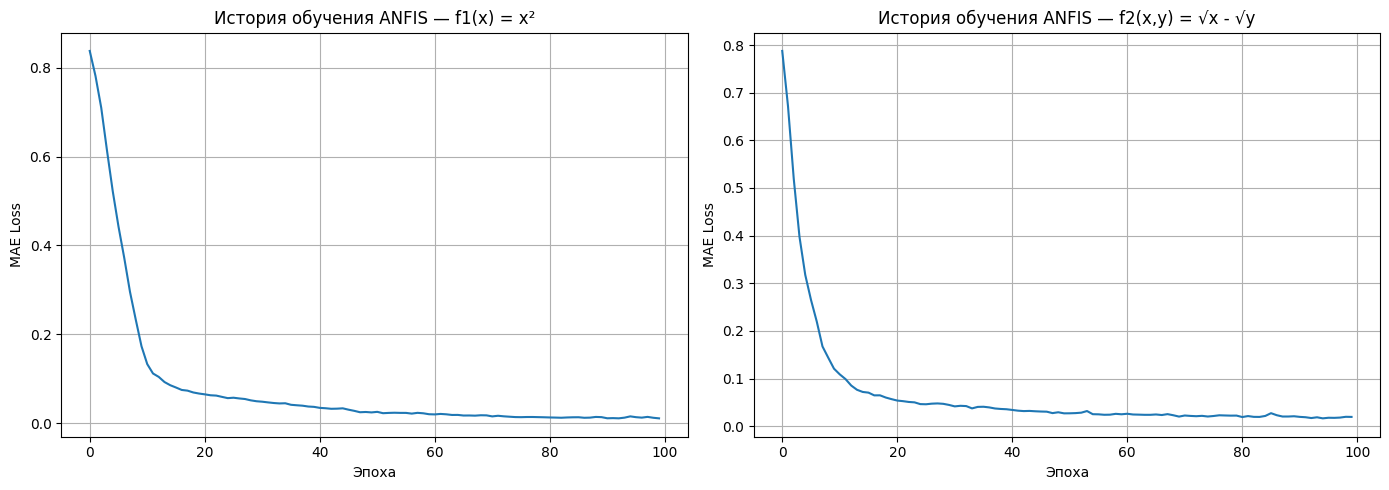

In [347]:
# Графики истории обучения ANFIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history_f1)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MAE Loss')
axes[0].set_title('История обучения ANFIS — f1(x) = x²')
axes[0].grid(True)

axes[1].plot(loss_history_f2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MAE Loss')
axes[1].set_title('История обучения ANFIS — f2(x,y) = √x - √y')
axes[1].grid(True)

plt.tight_layout()
plt.show()